In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
import zipfile
from pathlib import Path
import os

zip_file_path=Path(r'C:\\Users\\3PIN\Downloads\\archive.zip')
extract_dir=Path(r'C:\\Users\\3PIN\Downloads\\')
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path,'r') as file:
        file.extractall(extract_dir)
        print("Unzipped File Successfully!")
except FileNotFoundError as f:
    print("File not Found!")
except zipfile.BadZipFile as bd:
    print("Zipped File is corrupted!")
except Exception as e:
    print("Error:",e)

Unzipped File Successfully!


In [5]:
import tensorflow as tf 
import tensorflow.keras as keras
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,BatchNormalization,Dropout
from tensorflow.keras.models import Sequential

In [6]:
from pathlib import Path
train_ds=keras.utils.image_dataset_from_directory(
    directory=Path(r'C:\\Users\\3PIN\Downloads\\Flowers'),
    image_size=(128,128),
    label_mode='int',
    validation_split=0.2,
    batch_size=32,
    subset='training',
    shuffle=True,
    seed=42
    
)
test_ds=keras.utils.image_dataset_from_directory(
    directory=Path(r'C:\\Users\\3PIN\Downloads\\Flowers'),
    image_size=(128,128),
    label_mode='int',
    validation_split=0.2,
    batch_size=32,
    subset='validation',
    shuffle=True,
    seed=42
    
)


Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [7]:
class_names=train_ds.class_names

In [8]:
class_names

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

In [9]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [10]:
def process(image,label):
    image=image/255.0
    return (image,label)

In [11]:
train_ds=train_ds.map(process)
test_ds=test_ds.map(process)

In [12]:
len(class_names)

5

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False 

model = Sequential([
    base_model,
    GlobalAveragePooling2D(), 
    
    # 128 units kaafi hain, saath mein L2 regularization lagayi hai
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    # Dropout 0.1 se badha kar 0.5 kar diya
    Dropout(0.5),
    
    # Doosri Dense layer (64) hata di taaki model complex na ho
    
    Dense(5, activation='softmax') 
])

# Optimizer ka learning rate thoda kam rakho overfitting rokne ke liye
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [54]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,109 (9.24 MB)

 Trainable params: 164,869 (644.02 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [56]:
AUTOTUNE = tf.data.AUTOTUNE

# Cache data in memory (since data is small)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [57]:
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=test_ds)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 69s 475ms/step - accuracy: 0.7362 - loss: 2.7715 - val_accuracy: 0.8459 - val_loss: 2.0996
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 45s 413ms/step - accuracy: 0.8509 - loss: 1.8191 - val_accuracy: 0.8505 - val_loss: 1.5994
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 362ms/step - accuracy: 0.8816 - loss: 1.3357 - val_accuracy: 0.8575 - val_loss: 1.2351
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 62s 576ms/step - accuracy: 0.9056 - loss: 1.0070 - val_accuracy: 0.8459 - val_loss: 1.0674
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 44s 412ms/step - accuracy: 0.9013 - loss: 0.8366 - val_accuracy: 0.8470 - val_loss: 0.9546
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 63s 584ms/step - accuracy: 0.9184 - loss: 0.7153 - val_accuracy: 0.8586 - val_loss: 0.8739
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 42s 389ms/step - accuracy: 0.9047 - loss: 0.6688 - val_accuracy: 0.8470 - val_loss: 0.8363
Epoch 8/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 42s 387ms/step - accuracy: 0.9100 - loss: 0

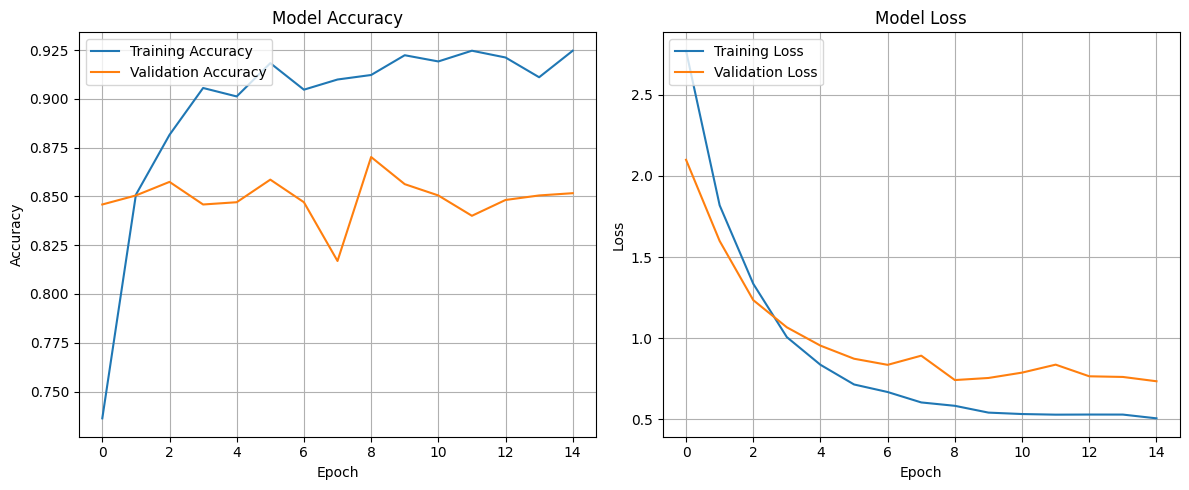

In [58]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )
plt.tight_layout()
plt.show()

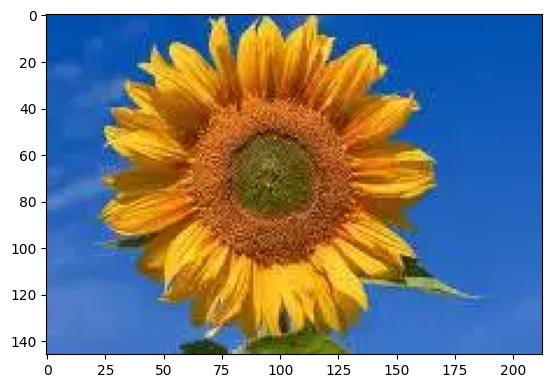

In [83]:
import cv2

test_img=cv2.imread(Path('C:\\Users\\3PIN\\Downloads\\dandelions.j'))
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB) # DON'T FORGET THIS
plt.imshow(test_img)

In [84]:
test_img=cv2.resize(test_img,(128,128))

test_input=test_img.reshape((1,128,128,3))

In [85]:
test_img = cv2.resize(test_img, (128, 128))
test_input = test_img / 255.0 # Scaling (Agar model mein Rescaling layer nahi hai)
test_input = np.expand_dims(test_input, axis=0)

In [86]:
predicted_class=np.argmax(model.predict(test_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


In [87]:
predicted_class

np.int64(3)

In [88]:
class_names[predicted_class]

'sunflower'